In [1]:
"""
=========================================================
03_feature_selection.py
=========================================================

Purpose
-------
Performs statistical feature selection before model training.

Outputs
-------
outputs/
    ├── feature_selection_report.csv
    ├── correlation_matrix.csv
    ├── vif.csv
    ├── selected_features.json
    └── correlation_heatmap.png
"""

'\n=========================================================\n03_feature_selection.py\n=========================================================\n\nPurpose\n-------\nPerforms statistical feature selection before model training.\n\nOutputs\n-------\noutputs/\n    ├── feature_selection_report.csv\n    ├── correlation_matrix.csv\n    ├── vif.csv\n    ├── selected_features.json\n    └── correlation_heatmap.png\n'

In [2]:
import json
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_selection import (
    mutual_info_classif,
    chi2
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
warnings.filterwarnings("ignore")

In [3]:
# ==========================================================
# Paths
# ==========================================================

BASE_DIR = Path.cwd().parent

INPUT_FILE = BASE_DIR /  "data" / "feature_engineered.csv"
FIGURE_PATH = BASE_DIR /"outputs"

In [4]:
# =====================================================
# LOAD DATA
# =====================================================

print("=" * 60)
print("Loading Feature Engineered Dataset")
print("=" * 60)

df = pd.read_csv(INPUT_FILE)

TARGET = "target"

Loading Feature Engineered Dataset


In [5]:
# =====================================================
# REMOVE ID COLUMN
# =====================================================

if "Client_Code" in df.columns:
    df = df.drop(columns=["Client_Code"])

In [6]:
# =====================================================
# DEFINE FEATURE TYPES
# =====================================================

categorical_features = [
    "Category_Bucket_final",
    "Vertical",
    "self_dealer_status",
    "plan",
    "Dealing_Zone"
]

numerical_features = [
    c
    for c in df.columns
    if c not in categorical_features + [TARGET]
]

print("\nNumerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))


Numerical Features: 13
Categorical Features: 5


In [7]:
# =====================================================
# CHI-SQUARE TEST
# =====================================================

print("\nRunning Chi-Square Tests...")

chi_results = []

for col in categorical_features:

    temp = df[[col, TARGET]].copy()

    temp[col] = temp[col].fillna("Missing")

    le = LabelEncoder()
    temp[col] = le.fit_transform(temp[col])

    score, p = chi2(temp[[col]], temp[TARGET])

    chi_results.append({
        "Feature": col,
        "Chi2 Score": score[0],
        "P-value": p[0]
    })

chi_df = pd.DataFrame(chi_results)


Running Chi-Square Tests...


In [8]:
# =====================================================
# MUTUAL INFORMATION
# =====================================================

print("Running Mutual Information...")

mi_df = df[numerical_features].copy()

mi_df = mi_df.fillna(0)

mi = mutual_info_classif(
    mi_df,
    df[TARGET],
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": numerical_features,
    "Mutual Information": mi
})

Running Mutual Information...


Calculating Correlation Matrix...


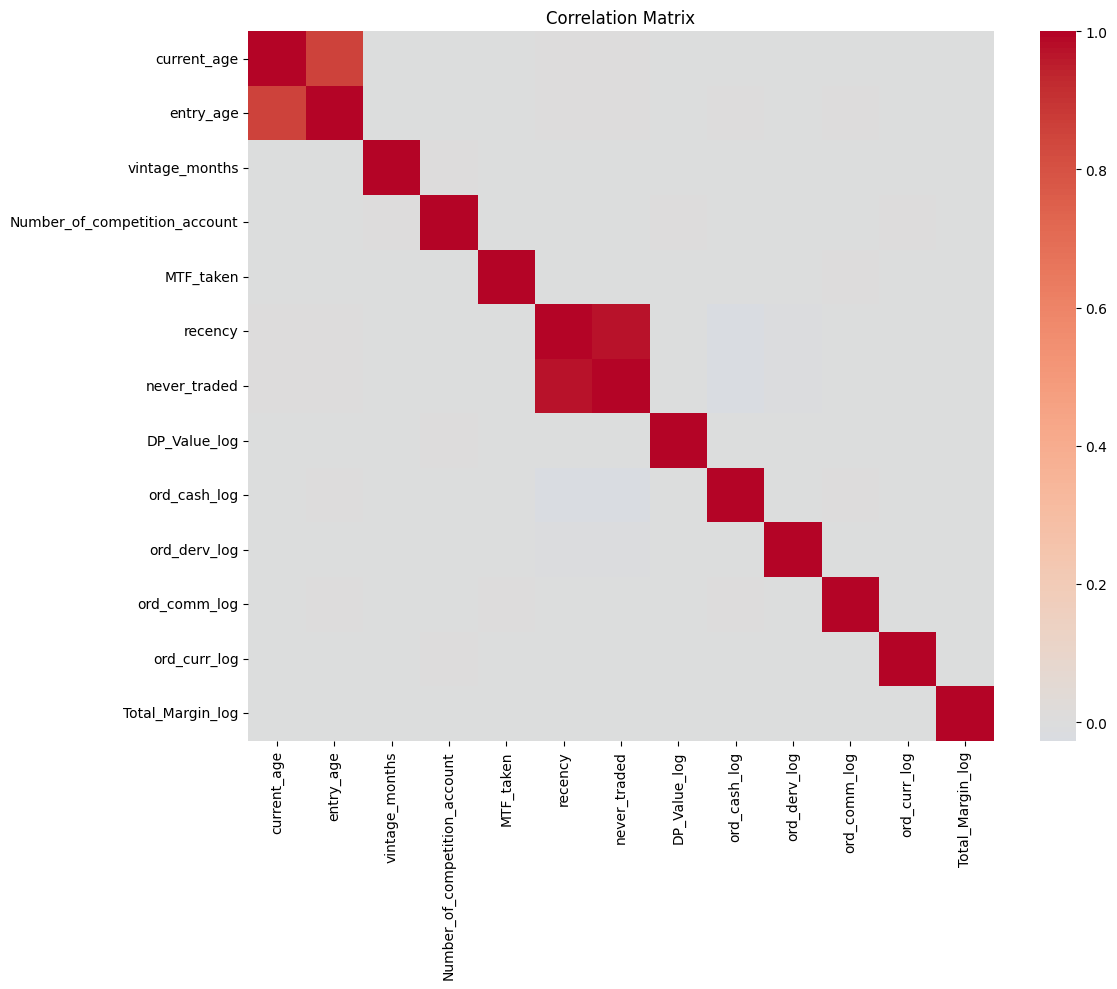

In [10]:
# =====================================================
# CORRELATION MATRIX
# =====================================================

print("Calculating Correlation Matrix...")

corr = df[numerical_features].corr()

corr.to_csv(
    f"{BASE_DIR}/outputs/correlation_matrix.csv",
    index=True
)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

plt.savefig(
   f"{FIGURE_PATH}/correlation_heatmap.png",
    dpi=300
)

plt.close()

In [11]:
# =====================================================
# HIGH CORRELATION DETECTION
# =====================================================

print("Finding Highly Correlated Features...")

pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):

        value = abs(corr.iloc[i, j])

        if value > 0.90:

            pairs.append({
                "Feature 1": corr.columns[i],
                "Feature 2": corr.columns[j],
                "Correlation": value
            })

high_corr = pd.DataFrame(pairs)

Finding Highly Correlated Features...


In [12]:
# =====================================================
# VIF
# =====================================================

print("Calculating VIF...")

vif_df = df[numerical_features].copy()

vif_df = vif_df.fillna(0)

scaler = MinMaxScaler()

vif_scaled = pd.DataFrame(
    scaler.fit_transform(vif_df),
    columns=vif_df.columns
)

vif = pd.DataFrame()

vif["Feature"] = vif_scaled.columns

vif["VIF"] = [

    variance_inflation_factor(
        vif_scaled.values,
        i
    )

    for i in range(vif_scaled.shape[1])

]

vif.to_csv(
    f"{FIGURE_PATH}vif.csv",
    index=False
)

Calculating VIF...


In [13]:
# =====================================================
# REMOVE REDUNDANT FEATURES
# =====================================================

print("Selecting Final Features...")

drop_features = [
    "entry_age",
    "DP_Value",
    "Total_Margin",
    "ord_cash",
    "ord_derv",
    "ord_comm",
    "ord_curr"
]

remaining = [

    c

    for c in df.columns

    if c not in drop_features + [TARGET]

]

Selecting Final Features...


In [14]:
# =====================================================
# FEATURE RANKING
# =====================================================

ranking = pd.DataFrame({
    "Feature": remaining
})

ranking = ranking.merge(
    mi_df,
    on="Feature",
    how="left"
)

ranking = ranking.merge(
    chi_df,
    on="Feature",
    how="left"
)

ranking["Importance"] = ranking[
    ["Mutual Information","Chi2 Score"]
].fillna(0).sum(axis=1)

ranking = ranking.sort_values(
    "Importance",
    ascending=False
)

ranking.to_csv(
   f"{FIGURE_PATH}/feature_selection_report.csv",
    index=False
)

In [15]:
# =====================================================
# SAVE SELECTED FEATURES
# =====================================================

selected_features = [
    "current_age",
    "vintage_months",
    "DP_Value_log",
    "Total_Margin_log",
    "ord_cash_log",
    "ord_derv_log",
    "Category_Bucket_final",
    "Vertical",
    "self_dealer_status",
    "Number_of_competition_account",
    "plan",
    "Dealing_Zone",
    "recency",
    "never_traded"
]

with open(
    f"{FIGURE_PATH}/selected_features.json",
    "w"
) as f:

    json.dump(
        selected_features,
        f,
        indent=4
    )

In [16]:
# =====================================================
# SUMMARY
# =====================================================

print("\n" + "=" * 60)
print("Feature Selection Complete")
print("=" * 60)

print(f"Total Features Before : {len(df.columns)-1}")
print(f"Selected Features     : {len(selected_features)}")

print("\nSaved Files")

print("feature_selection_report.csv")
print("correlation_matrix.csv")
print("vif.csv")
print("selected_features.json")
print("correlation_heatmap.png")


Feature Selection Complete
Total Features Before : 18
Selected Features     : 14

Saved Files
feature_selection_report.csv
correlation_matrix.csv
vif.csv
selected_features.json
correlation_heatmap.png
